<a href="https://colab.research.google.com/github/AndrsGzRo/prediccion-afluencia-metrocdmx/blob/main/Prediccion_Metro_CDMX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Afluencia del Metro de la Ciudad de México

## 1. Exploración preliminar del dataframe

In [94]:
# Importando librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
# Dataframe
url = 'https://github.com/AndrsGzRo/prediccion-afluencia-metrocdmx/raw/main/Afluencia_Diaria_MetroCDMX.zip'
df_raw = pd.read_csv(url,compression='zip')
df_raw.head()

,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499


### 1.1 Información sobre el dataframe

In [96]:
def info_df(df):
    print('---------Información general del Dataframe---------')
    print(df.info())
    print('---------Estadísticas del df---------')
    print(df.describe())
    print('---------Valores nulos---------')
    print(df.isnull().sum().sort_values(ascending=False))
    print('---------Valores únicos---------')
    print(df.nunique())

info_df(df_raw)

---------Información general del Dataframe---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1121640 entries, 0 to 1121639
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   fecha      1121640 non-null  object
 1   anio       1121640 non-null  int64 
 2   mes        1121640 non-null  object
 3   linea      1121640 non-null  object
 4   estacion   1121640 non-null  object
 5   afluencia  1121640 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 51.3+ MB
None
---------Estadísticas del df---------
               anio     afluencia
count  1.121640e+06  1.121640e+06
mean   2.017380e+03  1.969899e+04
std    4.547000e+00  1.947216e+04
min    2.010000e+03  0.000000e+00
25%    2.013000e+03  7.435000e+03
50%    2.017000e+03  1.445200e+04
75%    2.021000e+03  2.551000e+04
max    2.025000e+03  2.630560e+05
---------Valores nulos---------
fecha        0
anio         0
mes          0
linea        0
estacion     0
a

### 1.2 Convertir fecha a ```datetime```

In [97]:
df = df_raw.copy()
df['fecha'] = pd.to_datetime(df['fecha'],errors='coerce')
df['fecha'].dtype

dtype('<M8[ns]')

### 1.3 Convertir mes a número

In [98]:
meses = {
    'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,'Julio':7,
    'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12}

df['mes_num'] = df['mes'].map(meses)

df[['mes','mes_num']].head()

,mes,mes_num
0,Enero,1
1,Enero,1
2,Enero,1
3,Enero,1
4,Enero,1


### 1.4 Obtener día de la fecha

In [99]:
df['día'] = df['fecha'].dt.day
df['día_semana'] = df['fecha'].dt.day_name()
df['día_semana'] = df['día_semana'].replace({
    'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado',
    'Sunday':'Domingo'
})
df['día_semana'].unique()
df.head()

,fecha,anio,mes,linea,estacion,afluencia,mes_num,día,día_semana
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227,1,1,Viernes
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487,1,1,Viernes
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304,1,1,Viernes
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679,1,1,Viernes
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499,1,1,Viernes


### 1.5 Correción de nombre de las estaciones

In [100]:
df['estacion'] = df['estacion'].replace({
    'Isabel la CatÃ³lica':'Isabel la Católica', 'Pino SuÃ¡rez':'Pino Suárez',
    'GÃ³mez FarÃ\xadas':'Gómez Farías','La Villa/BasÃ\xadlica':'La Villa-Basílica',
    'PantitlÃ¡n':'Pantitlán','VelÃ³dromo':'Velódromo','RefinerÃ\xada':'Refinería',
    'EtiopÃ\xada/Plaza de la Transparencia':'Etiopía/ Plaza de la Transparencia',
    'DivisiÃ³n del Norte':'División del Norte',
    'FerrerÃ\xada/Arena Ciudad de MÃ©xico':'Ferretería/Arena Ciudad de México',
    'Instituto del PetrÃ³leo':'Instituto del Petróleo','San Juan de LetrÃ¡n':'San Juan Letrán',
    'OceanÃ\xada':'Ocenía','NezahualcÃ³yotl':'Nezahualcóyotl','RevoluciÃ³n':'Revolución',
    'JuÃ¡rez':'Juárez','OlÃ\xadmpica':'Olímpica','CulhuacÃ¡n':'Culhuacán',
    'PeÃ±Ã³n Viejo':'Peñón Viejo','San AndrÃ©s TomatlÃ¡n':'San Andrés Tomatlán',
    'AragÃ³n':'Aragón','MartÃ\xadn Carrera':'Martín Carrera','Aquiles SerdÃ¡n':'Aquiles Serdán',
    'San JoaquÃ\xadn':'San Joaquín','TezozÃ³moc':'Tezozómoc','CuitlÃ¡huac':'Cuitláhuac',
    'Terminal AÃ©rea':'Terminal Aérea','Centro MÃ©dico':'Centro Médico','CoyoacÃ¡n':'Coyoacán',
    'ZÃ³calo/Tenochtitlan':'Zócalo/Tenochtitlan','Boulevard Puerto AÃ©reo':'Boulevard Puerto Aéreo',
    'Villa de CortÃ©s':'Villa de Cortés','TalismÃ¡n':'Talismán','Valle GÃ³mez':'Valle Gómez',
    'PolitÃ©cnico':'Politécnico','NiÃ±os HÃ©roes':'Niños Héroes','TasqueÃ±a':'Tasqueña',
    'JuanacatlÃ¡n':'Juanacatlán','Plaza AragÃ³n':'Plaza Aragón','ZapotitlÃ¡n':'Zapotitlán',
    'RÃ\xado de los Remedios':'Río de los Remedios','MÃºzquiz':'Múzquiz',
    'EscuadrÃ³n 201':'Escuadrón 201','PerifÃ©rico Oriente':'Periférico Oriente',
    'TlÃ¡huac':'Tláhuac','San LÃ¡zaro':'San Lázaro','Villa de AragÃ³n':'Villa de Aragón',
    'AgrÃ\xadcola Oriental':'Agrícola Oriental','Deportivo OceanÃ\xada':'Deportivo Oceanía',
    'Bosque de AragÃ³n':'Bosque de Aragón','ConstituciÃ³n de 1917':'Constitución de 1917',
    'CuauhtÃ©moc':'Cuauhtémoc','Ricardo Flores MagÃ³n':'Ricardo Flores Magón',
    'LÃ¡zaro CÃ¡rdenas':'Lázaro Cárdenas','GÃ³mez Farias':'Gómez Farías',
    'PeÃ±Ã³n viejo':'Peñón Viejo','Miguel Ã\x81ngel de Quevedo':'Miguel Ángel de Quevedo'
})

### 1.6 Correción de Líneas

In [101]:
df['linea'].unique()

array(['Linea 1', 'Linea 6', 'Linea 9', 'Linea 8', 'Linea 5', 'Linea 7',
       'Linea 3', 'Linea 4', 'Linea 2', 'Linea B', 'Linea 12', 'Linea A',
       'LÃ\xadnea 1', 'LÃ\xadnea 12', 'LÃ\xadnea 2', 'LÃ\xadnea 3',
       'LÃ\xadnea 4', 'LÃ\xadnea 5', 'LÃ\xadnea 6', 'LÃ\xadnea 7',
       'LÃ\xadnea 8', 'LÃ\xadnea 9', 'LÃ\xadnea A', 'LÃ\xadnea B'],
      dtype=object)

In [102]:
# Reemplazar valores mal codificados de las líneas del Metro CDMX
df['linea'] = df['linea'].replace({
    'LÃ\xadnea 1': 'Línea 1','LÃ\xadnea 2': 'Línea 2','LÃ\xadnea 3': 'Línea 3',
    'LÃ\xadnea 4': 'Línea 4','LÃ\xadnea 5': 'Línea 5','LÃ\xadnea 6': 'Línea 6',
    'LÃ\xadnea 7': 'Línea 7','LÃ\xadnea 8': 'Línea 8','LÃ\xadnea 9': 'Línea 9',
    'LÃ\xadnea 12': 'Línea 12','LÃ\xadnea A': 'Línea A','LÃ\xadnea B': 'Línea B',
    'Linea 1':'Línea 1', 'Linea 6':'Línea 6','Linea 9':'Línea 9','Linea 8':'Línea 8',
    'Linea 5':'Línea 5','Linea 7':'Línea 7','Linea 3':'Línea 3','Linea 4':'Línea 4',
    'Linea 2':'Línea 2','Linea B':'Línea B','Linea 12':'Línea 12','Linea A':'Línea A'
})


### 1.7 Información Dataframe limpio

In [103]:
info_df(df)

---------Información general del Dataframe---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1121640 entries, 0 to 1121639
Data columns (total 9 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   fecha       1121640 non-null  datetime64[ns]
 1   anio        1121640 non-null  int64         
 2   mes         1121640 non-null  object        
 3   linea       1121640 non-null  object        
 4   estacion    1121640 non-null  object        
 5   afluencia   1121640 non-null  int64         
 6   mes_num     1121640 non-null  int64         
 7   día         1121640 non-null  int32         
 8   día_semana  1121640 non-null  object        
dtypes: datetime64[ns](1), int32(1), int64(3), object(4)
memory usage: 72.7+ MB
None
---------Estadísticas del df---------
                               fecha          anio     afluencia  \
count                        1121640  1.121640e+06  1.121640e+06   
mean   2017-11-15 11:59:59.

## 2. Visualizaciones para entender el Dataframe

In [104]:
sns.set_theme(style='darkgrid')
metro_color = '#FE5000'

### 2.1 Evolución de Afluencia

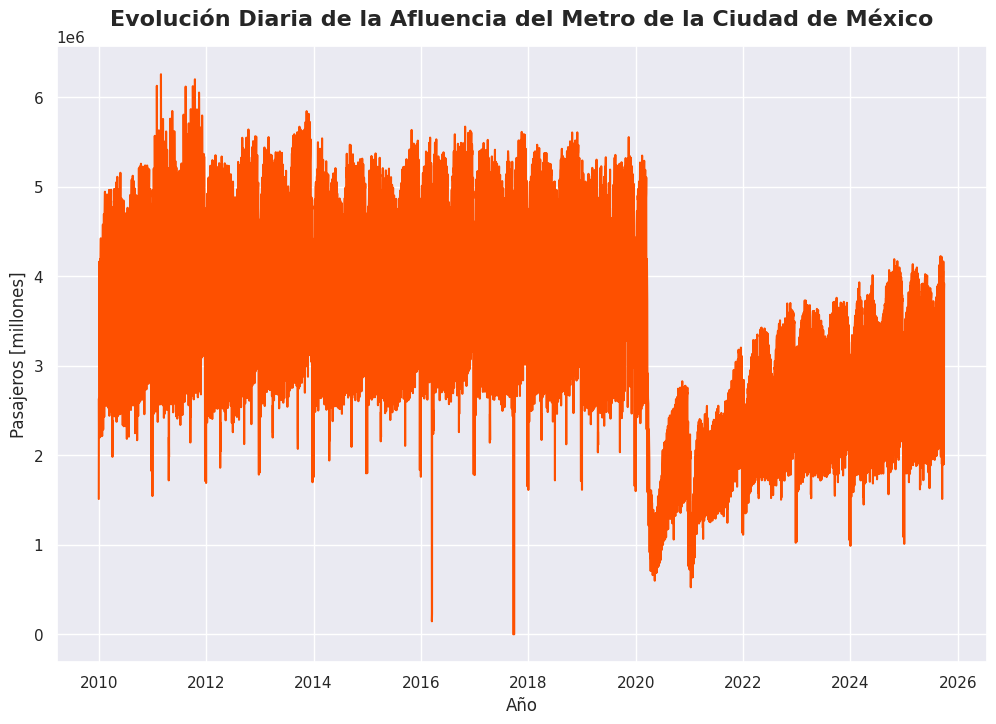

In [105]:
afluencia_fecha = (
    df.groupby('fecha')['afluencia'].sum().reset_index(name='Afluencia')
)

# Visualización
plt.figure(figsize=(12,8))
sns.lineplot(
    data=afluencia_fecha,x='fecha',
    y='Afluencia',color=metro_color)
plt.xlabel('Año',fontsize=12)
plt.ylabel('Pasajeros [millones]',fontsize=12)
plt.title('Evolución Diaria de la Afluencia del Metro de la Ciudad de México',
          fontsize=16,fontweight='bold',pad=15)
plt.show()

### 2.2 Afluencia promedio por línea

In [110]:
afluenciaprom_linea = (
    df.groupby('linea')['afluencia'].mean().sort_values(ascending=False).reset_index(name='Afluencia')
)
